# Travel Reimbursement Approval Agent

**Author:** Balagani Ganesh
**Model:** Google Gemini 2.5 Flash (via Google AI Studio)  
**Framework:** Python + `google-genai` SDK with function-calling (agentic loop)

---

## README -- Setup & How to Run

### Prerequisites
```
Python 3.10+
Jupyter Notebook or JupyterLab
```

### Environment Variables
Set your Google AI Studio API key:
```bash
# Option A -- shell export
export GOOGLE_API_KEY=""

# Option B -- enter directly in Cell 3 when prompted (secure getpass)
```
Get a free key at: https://aistudio.google.com/app/apikey

### How to Run
1. Install dependencies (Cell 2 runs automatically)  
2. Set your API key (Cell 3 prompts securely if not set)  
3. **Kernel > Restart & Run All** -- runs end-to-end without manual steps  
4. Cell 11 outputs the structured JSON results array  
5. Cell 12 renders the decision dashboard inline and saves `UI SS_1.png`

### Key Design Choices
- **Agentic loop**: Gemini function-calling in a `while` loop until no more tool calls (genuine agency)  
- **Policy as code**: All POL-* rules stored as Python dicts, injected into system prompt + callable as tools  
- **Prefer Manual Review**: Any ambiguity routes to MANUAL_REVIEW per policy guidance  
- **Deterministic tools**: Per-diem math, receipt checks, and threshold lookups are Python functions (not LLM)  
- **Zero hallucinated data**: Only the 5 claims from Appendix B and the policy from Appendix A are used


In [1]:
# Cell 2: Install Dependencies
import importlib.util
import subprocess
import sys

packages = ['google-genai', 'pandas', 'matplotlib', 'pydantic', 'python-dateutil']

MODULE_ALIASES = {
    'google-genai': 'google.genai',
    'python-dateutil': 'dateutil',
}


def ensure_package(pkg: str) -> None:
    module_name = MODULE_ALIASES.get(pkg, pkg.replace('-', '_'))
    if importlib.util.find_spec(module_name):
        print(f'{pkg} already available in the active environment.')
        return

    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'{pkg} installed successfully.')
    except subprocess.CalledProcessError as exc:
        print(f'Warning: could not install {pkg} automatically (exit code {exc.returncode}).')
        print('The notebook will continue; if imports still fail, install it manually in the active kernel environment.')


for pkg in packages:
    ensure_package(pkg)

print('Dependency check complete.')

google-genai already available in the active environment.
pandas already available in the active environment.
matplotlib already available in the active environment.
pydantic already available in the active environment.
python-dateutil already available in the active environment.
Dependency check complete.


In [2]:
# Cell 3: API Key Configuration
import os
import getpass

if 'GOOGLE_API_KEY' not in os.environ or not os.environ['GOOGLE_API_KEY']:
    try:
        from google.colab import userdata
        os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
        print('API key loaded from Colab userdata.')
    except Exception:
        key = getpass.getpass('Enter your Google AI Studio API key: ')
        if key:
            os.environ['GOOGLE_API_KEY'] = key
            print('API key set for this session.')
        else:
            print('No API key provided. Cell 9 will fail until a valid key is set.')
else:
    print('GOOGLE_API_KEY found in environment.')

API_KEY = os.environ.get('GOOGLE_API_KEY', '')
MODEL_NAME = os.environ.get('GEMINI_MODEL', 'gemini-3.1-flash-lite')
print(f'Model: {MODEL_NAME}')

API key set for this session.
Model: gemini-3.1-flash-lite


---
## Policy Reference -- Appendix A

All rules have stable `POL-*` IDs cited in the structured output.

| Rule ID | Category | Rule Summary |
|---------|----------|--------------|
| POL-CAT-01 | Eligible | Airfare (economy), Lodging, Meals, Ground transport, Conference fees |
| POL-CAT-02 | Ineligible | Alcohol, minibar, spa, gym, entertainment, fines, personal items |
| POL-PD-01 | Per-diem | Meals <= $75/day |
| POL-PD-02 | Per-diem | Lodging <= $200/night |
| POL-PD-03 | Per-diem | Ground transport <= $50/day |
| POL-AIR-01 | Airfare | Economy only; business/first class -> Manual Review |
| POL-RCT-01 | Receipts | Receipt required for any single item > $25; always for airfare & lodging |
| POL-RCT-02 | Receipts | Missing receipt -> Manual Review (not auto-reject) |
| POL-APR-01 | Approval | Total <= $500 -> Auto-approve |
| POL-APR-02 | Approval | $500 < Total <= $2,000 -> Manager approval (approvable if compliant) |
| POL-APR-03 | Approval | Total > $2,000 -> Director / Manual Review |
| POL-TIME-01 | Timeliness | Claim must be submitted within 30 days of expense date |


In [3]:
# Cell 5: Policy Data Structures

# Per-diem limits (USD)
PER_DIEM_LIMITS = {
    'meals':            {'daily_limit': 75.0,  'policy': 'POL-PD-01'},
    'lodging':          {'daily_limit': 200.0, 'policy': 'POL-PD-02'},
    'ground_transport': {'daily_limit': 50.0,  'policy': 'POL-PD-03'},
}

# Ineligible categories (POL-CAT-02)
INELIGIBLE_CATEGORIES = {
    'spa', 'gym', 'minibar', 'alcohol', 'entertainment',
    'personal_shopping', 'gifts', 'traffic_fine', 'personal',
    'in_room_movie', 'penalty', 'late_fee',
}

# Eligible categories (POL-CAT-01)
ELIGIBLE_CATEGORIES = {
    'airfare', 'lodging', 'meals', 'ground_transport',
    'conference_fees', 'registration_fees', 'taxi', 'rideshare',
    'train', 'rental_car', 'parking',
}

# Approval thresholds
APPROVAL_THRESHOLDS = [
    {'max': 500,          'tier': 'AUTO',     'policy': 'POL-APR-01', 'decision_eligible': True},
    {'max': 2000,         'tier': 'MANAGER',  'policy': 'POL-APR-02', 'decision_eligible': True},
    {'max': float('inf'), 'tier': 'DIRECTOR', 'policy': 'POL-APR-03', 'decision_eligible': False},
]

# Policy rule text for lookup
POLICY_RULES = {
    'POL-CAT-01': 'Eligible categories: Airfare (economy class only), Lodging (hotel room charges), Meals (subject to per-diem limits), Ground transport (taxi, rideshare, train, rental car, parking), Conference/registration fees.',
    'POL-CAT-02': 'Ineligible items (never reimbursable): Alcohol and minibar charges, Spa/gym/personal entertainment, In-room movies, personal shopping, gifts, Traffic fines/penalties/late fees, Any personal (non-business) expense.',
    'POL-PD-01':  'Meals: Maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.',
    'POL-PD-02':  'Lodging: Maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.',
    'POL-PD-03':  'Ground transport: Maximum $50 per day. Amounts above the cap are deducted.',
    'POL-AIR-01': 'Airfare class: Only economy class is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (pre-approval may exist).',
    'POL-RCT-01': 'Receipt required above $25: Any single line item > $25 requires an attached, itemized receipt. Airfare and lodging ALWAYS require a receipt regardless of amount.',
    'POL-RCT-02': 'Missing receipt handling: If a receipt is missing for an item that requires one, the claim is routed to Manual Review so the reviewer can request the receipt.',
    'POL-APR-01': 'Auto-approve tier: Total reimbursable <= $500 may be auto-approved if fully compliant.',
    'POL-APR-02': 'Manager tier: Total > $500 and <= $2,000 is eligible for approval when fully compliant.',
    'POL-APR-03': 'Director/Manual-Review tier: Total > $2,000 must be routed to Manual Review (director approval required).',
    'POL-TIME-01': 'Submission window: Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.',
}

SUBMISSION_WINDOW_DAYS = 30

print('Policy data structures initialized.')
print(f'  Eligible categories   : {len(ELIGIBLE_CATEGORIES)}')
print(f'  Ineligible categories : {len(INELIGIBLE_CATEGORIES)}')
print(f'  Policy rules indexed  : {len(POLICY_RULES)}')

Policy data structures initialized.
  Eligible categories   : 11
  Ineligible categories : 12
  Policy rules indexed  : 12


In [4]:
# Cell 6: Tool Definitions
# Five tools implemented as pure Python functions, exposed to Gemini via function declarations.

import json
from datetime import date, datetime

# --- Tool 1: Policy Rule Lookup -------------------------------------------
def lookup_policy_rule(rule_id: str) -> dict:
    """Returns the full text of a specific policy rule by its stable POL-* ID."""
    if rule_id in POLICY_RULES:
        return {'rule_id': rule_id, 'text': POLICY_RULES[rule_id], 'found': True}
    if rule_id.upper() == 'ALL':
        return {'rules': POLICY_RULES, 'found': True, 'count': len(POLICY_RULES)}
    return {'rule_id': rule_id, 'found': False, 'text': 'Rule not found in policy database.'}


# --- Tool 2: Receipt Completeness Check -----------------------------------
def check_receipt_completeness(line_items: list) -> dict:
    """
    Checks which line items are missing required receipts per POL-RCT-01.
    Airfare and lodging ALWAYS require a receipt.
    Any item > $25 requires a receipt.
    """
    ALWAYS_REQUIRE = {'airfare', 'lodging'}
    missing, compliant = [], []
    for item in line_items:
        cat = item.get('category', '').lower()
        amount = float(item.get('amount', 0))
        has_receipt = bool(item.get('receipt_attached', False))
        desc = item.get('description', cat)
        needs_receipt = (cat in ALWAYS_REQUIRE) or (amount > 25.0)
        if needs_receipt and not has_receipt:
            reason = 'always required for ' + cat if cat in ALWAYS_REQUIRE else 'amount > $25'
            missing.append({'category': cat, 'description': desc, 'amount': amount,
                            'reason': f'Receipt required (POL-RCT-01): {reason}',
                            'policy': 'POL-RCT-01'})
        else:
            compliant.append({'category': cat, 'description': desc, 'amount': amount, 'receipt_ok': True})
    return {
        'missing_receipt_items': missing,
        'compliant_items': compliant,
        'requires_manual_review': len(missing) > 0,
        'applicable_policies': ['POL-RCT-01', 'POL-RCT-02'],
        'guidance': 'Route to MANUAL_REVIEW if any items appear in missing_receipt_items (POL-RCT-02).',
    }


# --- Tool 3: Per-Diem & Category Limit Calculator -------------------------
def calculate_per_diem_limits(line_items: list, trip_days: int) -> dict:
    """
    Calculates the allowed vs claimed amounts for each line item.
    Applies per-diem caps and identifies ineligible categories (POL-CAT-02).
    """
    results = []
    total_claimed = total_reimbursable = total_deducted = 0.0
    ineligible_found = []
    policy_refs = set()

    for item in line_items:
        cat = item.get('category', '').lower()
        amount = float(item.get('amount', 0))
        desc = item.get('description', cat)
        is_business_class = item.get('is_business_class', False)
        days = item.get('days', trip_days)
        total_claimed += amount

        # Check ineligible category (POL-CAT-02)
        is_ineligible = any(kw in cat for kw in INELIGIBLE_CATEGORIES)
        if is_ineligible:
            ineligible_found.append({'category': cat, 'description': desc, 'amount': amount})
            results.append({'category': cat, 'description': desc,
                            'claimed': amount, 'allowed': 0.0, 'reimbursable': 0.0,
                            'deducted': amount, 'status': 'REJECTED_INELIGIBLE', 'policy': 'POL-CAT-02'})
            total_deducted += amount
            policy_refs.add('POL-CAT-02')
            continue

        # Business class airfare (POL-AIR-01)
        if cat == 'airfare' and is_business_class:
            results.append({'category': cat, 'description': desc,
                            'claimed': amount, 'allowed': None, 'reimbursable': amount,
                            'deducted': 0.0, 'status': 'MANUAL_REVIEW_REQUIRED', 'policy': 'POL-AIR-01',
                            'note': 'Business/first-class airfare -> Manual Review (pre-approval may exist)'})
            total_reimbursable += amount
            policy_refs.add('POL-AIR-01')
            continue

        # Per-diem / nightly limits
        if cat in PER_DIEM_LIMITS:
            limit_info = PER_DIEM_LIMITS[cat]
            daily_limit = limit_info['daily_limit']
            total_limit = daily_limit * days
            allowed = min(amount, total_limit)
            excess = max(0.0, amount - total_limit)
            status = 'WITHIN_LIMIT' if excess == 0 else 'EXCEEDS_LIMIT'
            results.append({'category': cat, 'description': desc,
                            'claimed': amount, 'allowed': total_limit,
                            'reimbursable': round(allowed, 2), 'deducted': round(excess, 2),
                            'status': status, 'policy': limit_info['policy'],
                            'note': f'Limit: ${daily_limit}/unit x {days} units = ${total_limit}'})
            total_reimbursable += allowed
            total_deducted += excess
            policy_refs.add(limit_info['policy'])
            policy_refs.add('POL-CAT-01')
            continue

        # Eligible category with no per-diem cap
        if cat in ELIGIBLE_CATEGORIES:
            results.append({'category': cat, 'description': desc,
                            'claimed': amount, 'allowed': None,
                            'reimbursable': amount, 'deducted': 0.0,
                            'status': 'ELIGIBLE_NO_CAP', 'policy': 'POL-CAT-01'})
            total_reimbursable += amount
            policy_refs.add('POL-CAT-01')
            continue

        # Unknown category
        results.append({'category': cat, 'description': desc,
                        'claimed': amount, 'allowed': None,
                        'reimbursable': 0.0, 'deducted': 0.0,
                        'status': 'UNKNOWN_CATEGORY',
                        'note': 'Category not in policy -- route to Manual Review.'})
        policy_refs.add('POL-CAT-01')

    return {
        'line_item_results': results,
        'total_claimed': round(total_claimed, 2),
        'total_reimbursable': round(total_reimbursable, 2),
        'total_deducted': round(total_deducted, 2),
        'ineligible_items': ineligible_found,
        'applicable_policies': list(policy_refs),
    }


# --- Tool 4: Approval Threshold Check ------------------------------------
def check_approval_threshold(total_reimbursable: float) -> dict:
    """Maps the reimbursable total to an approval tier. Returns whether agent can approve."""
    for tier in APPROVAL_THRESHOLDS:
        if total_reimbursable <= tier['max']:
            return {
                'total_reimbursable': total_reimbursable,
                'tier': tier['tier'],
                'policy': tier['policy'],
                'agent_can_approve': tier['decision_eligible'],
                'requires_manual_review': not tier['decision_eligible'],
                'guidance': (
                    'Agent may approve if all other checks pass.'
                    if tier['decision_eligible']
                    else 'Amount exceeds $2,000 -- route to MANUAL_REVIEW (director approval required).'
                ),
            }


# --- Tool 5: Timeliness Check --------------------------------------------
def check_timeliness(trip_end_date: str, submission_date: str) -> dict:
    """Checks whether the claim was submitted within 30 days of the trip end date (POL-TIME-01)."""
    try:
        from dateutil import parser as dparser
        end = dparser.parse(trip_end_date).date()
        sub = dparser.parse(submission_date).date()
        days_diff = (sub - end).days
        compliant = days_diff <= SUBMISSION_WINDOW_DAYS
        return {
            'trip_end_date': trip_end_date, 'submission_date': submission_date,
            'days_after_trip': days_diff, 'window_days': SUBMISSION_WINDOW_DAYS,
            'compliant': compliant, 'policy': 'POL-TIME-01',
            'guidance': (
                'Submission is within the 30-day window.' if compliant
                else f'LATE: {days_diff} days after trip end (limit: {SUBMISSION_WINDOW_DAYS}). Route to MANUAL_REVIEW.'
            ),
        }
    except Exception as e:
        return {'error': str(e), 'compliant': None, 'policy': 'POL-TIME-01'}


# --- Tool Registry -------------------------------------------------------
TOOL_REGISTRY = {
    'lookup_policy_rule': lookup_policy_rule,
    'check_receipt_completeness': check_receipt_completeness,
    'calculate_per_diem_limits': calculate_per_diem_limits,
    'check_approval_threshold': check_approval_threshold,
    'check_timeliness': check_timeliness,
}

print(f'{len(TOOL_REGISTRY)} tools registered:')
for name in TOOL_REGISTRY:
    print(f'  * {name}')

5 tools registered:
  * lookup_policy_rule
  * check_receipt_completeness
  * calculate_per_diem_limits
  * check_approval_threshold
  * check_timeliness


In [5]:
# Cell 7: Gemini Client + Agentic Orchestrator
import json
from typing import Any
from google import genai
from google.genai import types

# Initialize Gemini Client
if not API_KEY:
    print('No Google API key detected. The notebook will use deterministic fallback logic instead of calling Gemini.')
    client = None
else:
    try:
        client = genai.Client(api_key=API_KEY)
    except Exception as exc:
        print(f'Gemini client initialization failed: {exc}')
        client = None


# Gemini Function Declarations -- mirror the Python tool signatures
GEMINI_TOOLS = [
    types.Tool(function_declarations=[
        types.FunctionDeclaration(
            name='lookup_policy_rule',
            description='Look up the text of a specific travel policy rule by its POL-* ID. Pass rule_id="ALL" to retrieve all rules.',
            parameters=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    'rule_id': types.Schema(type=types.Type.STRING,
                                           description='The stable policy rule ID, e.g. "POL-PD-01".')
                },
                required=['rule_id']
            )
        ),
        types.FunctionDeclaration(
            name='check_receipt_completeness',
            description='Check which line items are missing required receipts (POL-RCT-01). Each item: category, description, amount, receipt_attached (bool).',
            parameters=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    'line_items': types.Schema(
                        type=types.Type.ARRAY,
                        description='Array of line item objects.',
                        items=types.Schema(
                            type=types.Type.OBJECT,
                            properties={
                                'category': types.Schema(type=types.Type.STRING),
                                'description': types.Schema(type=types.Type.STRING),
                                'amount': types.Schema(type=types.Type.NUMBER),
                                'receipt_attached': types.Schema(type=types.Type.BOOLEAN),
                            }
                        )
                    )
                },
                required=['line_items']
            )
        ),
        types.FunctionDeclaration(
            name='calculate_per_diem_limits',
            description='Calculate allowed vs claimed amounts. Applies per-diem caps and identifies ineligible items. Set is_business_class=true for business-class airfare.',
            parameters=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    'line_items': types.Schema(
                        type=types.Type.ARRAY,
                        description='Array of line items with category, description, amount, days (optional), is_business_class (optional).',
                        items=types.Schema(
                            type=types.Type.OBJECT,
                            properties={
                                'category': types.Schema(type=types.Type.STRING),
                                'description': types.Schema(type=types.Type.STRING),
                                'amount': types.Schema(type=types.Type.NUMBER),
                                'days': types.Schema(type=types.Type.INTEGER),
                                'is_business_class': types.Schema(type=types.Type.BOOLEAN),
                            }
                        )
                    ),
                    'trip_days': types.Schema(type=types.Type.INTEGER,
                                              description='Total trip days/nights (default when item-level days not specified).')
                },
                required=['line_items', 'trip_days']
            )
        ),
        types.FunctionDeclaration(
            name='check_approval_threshold',
            description='Maps total reimbursable to an approval tier: AUTO (<=500), MANAGER (<=2000), DIRECTOR (>2000).',
            parameters=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    'total_reimbursable': types.Schema(type=types.Type.NUMBER,
                                                       description='Net reimbursable amount after per-diem deductions, in USD.')
                },
                required=['total_reimbursable']
            )
        ),
        types.FunctionDeclaration(
            name='check_timeliness',
            description='Verifies claim submitted within 30 days of trip end (POL-TIME-01). Dates in YYYY-MM-DD format.',
            parameters=types.Schema(
                type=types.Type.OBJECT,
                properties={
                    'trip_end_date': types.Schema(type=types.Type.STRING,
                                                   description='ISO 8601 date of last day of travel.'),
                    'submission_date': types.Schema(type=types.Type.STRING,
                                                    description='ISO 8601 date the claim was submitted.')
                },
                required=['trip_end_date', 'submission_date']
            )
        ),
    ])
]

SYSTEM_PROMPT = """\
You are a Travel Reimbursement Approval Agent. Evaluate employee travel expense claims
against the company travel policy and produce a structured JSON decision.

## Policy Summary
- POL-CAT-01: Eligible -- airfare (economy), lodging, meals, ground transport, conference fees
- POL-CAT-02: Ineligible -- alcohol, minibar, spa, gym, entertainment, fines, personal items
- POL-PD-01: Meals <= $75/day
- POL-PD-02: Lodging <= $200/night
- POL-PD-03: Ground transport <= $50/day
- POL-AIR-01: Economy only; business/first class -> MANUAL_REVIEW
- POL-RCT-01: Receipt required for items > $25, always for airfare & lodging
- POL-RCT-02: Missing receipt -> MANUAL_REVIEW (not auto-reject)
- POL-APR-01: Total <= $500 -> auto-approvable
- POL-APR-02: $500 < Total <= $2,000 -> manager-approvable (approve if compliant)
- POL-APR-03: Total > $2,000 -> MANUAL_REVIEW (director required)
- POL-TIME-01: Claim within 30 days of trip end; late -> MANUAL_REVIEW

## Decision Rules
- APPROVE: All items eligible, all receipts present, within per-diem, within approvable tier
- PARTIAL_APPROVE: Valid claim but some amounts exceed per-diem caps; reimburse up to cap, deduct excess
- REJECT: All claimed items are ineligible (POL-CAT-02) with nothing reimbursable
- MANUAL_REVIEW: Any ambiguity, policy exception, high value (POL-APR-03), missing receipt, or conflicting info

## IMPORTANT
- Always prefer MANUAL_REVIEW over forcing an incorrect decision
- Always call check_timeliness, check_receipt_completeness, calculate_per_diem_limits, and check_approval_threshold
- Cite specific POL-* IDs in your response

## Output Format
After using tools, respond ONLY with a JSON object (no markdown fences, no extra text):
{
  "claim_id": "CLM-XXX",
  "decision": "APPROVE|PARTIAL_APPROVE|REJECT|MANUAL_REVIEW",
  "approved_amount": 0.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": ["POL-XXX-YY"],
  "confidence": 0.95,
  "explanation": "...",
  "tools_used": ["tool_name"]
}
"""


def execute_tool(tool_name: str, tool_args: dict) -> Any:
    """Execute a registered tool and return its result."""
    if tool_name not in TOOL_REGISTRY:
        return {'error': f'Tool "{tool_name}" not found in registry.'}
    try:
        return TOOL_REGISTRY[tool_name](**tool_args)
    except Exception as e:
        return {'error': str(e), 'tool': tool_name, 'args': tool_args}


def _build_fallback_result(claim: dict, tool_results: dict, tools_used: list) -> dict:
    claim_id = claim.get('claim_id', 'UNKNOWN')
    timeliness = tool_results['check_timeliness']
    receipt = tool_results['check_receipt_completeness']
    per_diem = tool_results['calculate_per_diem_limits']
    approval = tool_results['check_approval_threshold']

    policy_refs = set()
    policy_refs.update(receipt.get('applicable_policies', []))
    policy_refs.update(per_diem.get('applicable_policies', []))
    policy_refs.add(approval.get('policy', 'POL-APR-01'))
    if not timeliness.get('compliant', True):
        policy_refs.add('POL-TIME-01')

    missing_docs = [item.get('description', item.get('category', 'unknown')) for item in receipt.get('missing_receipt_items', [])]
    has_ineligible = any(item.get('status') == 'REJECTED_INELIGIBLE' for item in per_diem.get('line_item_results', []))
    requires_manual_review = (
        not timeliness.get('compliant', True)
        or receipt.get('requires_manual_review', False)
        or approval.get('requires_manual_review', False)
        or any(item.get('status') == 'MANUAL_REVIEW_REQUIRED' for item in per_diem.get('line_item_results', []))
    )

    if has_ineligible and per_diem.get('total_reimbursable', 0) <= 0:
        decision = 'REJECT'
    elif requires_manual_review:
        decision = 'MANUAL_REVIEW'
    elif per_diem.get('total_deducted', 0) > 0:
        decision = 'PARTIAL_APPROVE'
    elif approval.get('agent_can_approve', False):
        decision = 'APPROVE'
    else:
        decision = 'MANUAL_REVIEW'

    return {
        'claim_id': claim_id,
        'decision': decision,
        'approved_amount': round(float(per_diem.get('total_reimbursable', 0)), 2),
        'deducted_amount': round(float(per_diem.get('total_deducted', 0)), 2),
        'missing_docs': missing_docs,
        'policy_refs': sorted(policy_refs),
        'confidence': 0.78 if decision == 'MANUAL_REVIEW' else 0.86,
        'explanation': 'Fallback policy-based decision used because Gemini was unavailable or rejected the request.',
        'tools_used': sorted(tools_used),
    }


def process_claim(claim: dict, verbose: bool = True) -> dict:
    """
    Agentic loop: send claim to Gemini, execute tool calls, feed results back,
    repeat until a final text response is received, then parse the JSON decision.
    """
    claim_id = claim.get('claim_id', 'UNKNOWN')
    if verbose:
        print(f'\n{"="*60}')
        print(f'[{claim_id}] {claim.get("purpose", "")}')
        print(f'  Employee: {claim.get("employee", "")} | Total: ${claim.get("total_claimed", 0):.2f}')

    if client is None:
        if verbose:
            print('  Gemini unavailable; using deterministic fallback logic.')
        tool_results = {
            'check_timeliness': execute_tool('check_timeliness', {
                'trip_end_date': claim.get('trip_end', ''),
                'submission_date': claim.get('submission_date', ''),
            }),
            'check_receipt_completeness': execute_tool('check_receipt_completeness', {
                'line_items': claim.get('line_items', []),
            }),
            'calculate_per_diem_limits': execute_tool('calculate_per_diem_limits', {
                'line_items': claim.get('line_items', []),
                'trip_days': claim.get('trip_days', 0),
            }),
            'check_approval_threshold': execute_tool('check_approval_threshold', {
                'total_reimbursable': execute_tool('calculate_per_diem_limits', {
                    'line_items': claim.get('line_items', []),
                    'trip_days': claim.get('trip_days', 0),
                }).get('total_reimbursable', 0),
            }),
        }
        tools_used = ['check_timeliness', 'check_receipt_completeness', 'calculate_per_diem_limits', 'check_approval_threshold']
        return _build_fallback_result(claim, tool_results, tools_used)

    user_message = f"""Evaluate this travel reimbursement claim and produce a decision.

Claim JSON:
{json.dumps(claim, indent=2)}

Steps:
1. Call check_timeliness with trip_end_date and submission_date
2. Call check_receipt_completeness with all line_items
3. Call calculate_per_diem_limits with all line_items and trip_days
4. Call check_approval_threshold with the net reimbursable amount
5. Optionally call lookup_policy_rule for any specific rule you want to cite
6. Produce the final JSON decision object
"""

    conversation_history = [
        types.Content(role='user', parts=[types.Part(text=user_message)])
    ]

    tools_used = set()
    max_turns = 10
    turn = 0

    while turn < max_turns:
        turn += 1
        if verbose:
            print(f'  Turn {turn}: calling Gemini...')

        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=conversation_history,
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    tools=GEMINI_TOOLS,
                    temperature=0.1,
                )
            )
        except Exception as exc:
            if verbose:
                print(f'  Gemini call failed: {exc}')
            tool_results = {
                'check_timeliness': execute_tool('check_timeliness', {
                    'trip_end_date': claim.get('trip_end', ''),
                    'submission_date': claim.get('submission_date', ''),
                }),
                'check_receipt_completeness': execute_tool('check_receipt_completeness', {
                    'line_items': claim.get('line_items', []),
                }),
                'calculate_per_diem_limits': execute_tool('calculate_per_diem_limits', {
                    'line_items': claim.get('line_items', []),
                    'trip_days': claim.get('trip_days', 0),
                }),
                'check_approval_threshold': execute_tool('check_approval_threshold', {
                    'total_reimbursable': execute_tool('calculate_per_diem_limits', {
                        'line_items': claim.get('line_items', []),
                        'trip_days': claim.get('trip_days', 0),
                    }).get('total_reimbursable', 0),
                }),
            }
            tools_used = ['check_timeliness', 'check_receipt_completeness', 'calculate_per_diem_limits', 'check_approval_threshold']
            return _build_fallback_result(claim, tool_results, tools_used)

        conversation_history.append(response.candidates[0].content)

        function_calls = [
            part for part in response.candidates[0].content.parts
            if hasattr(part, 'function_call') and part.function_call is not None
        ]

        if not function_calls:
            text = ''.join(
                part.text for part in response.candidates[0].content.parts
                if hasattr(part, 'text') and part.text
            )
            if verbose:
                print(f'  Decision received after {turn} turns. Tools used: {sorted(tools_used)}')
            try:
                clean = text.strip()
                if clean.startswith('```'):
                    clean = clean.split('```')[1]
                    if clean.startswith('json'):
                        clean = clean[4:]
                result = json.loads(clean.strip())
                result['tools_used'] = sorted(tools_used)
                return result
            except json.JSONDecodeError as e:
                if verbose:
                    print(f'  WARNING: JSON parse error: {e}')
                return {
                    'claim_id': claim_id, 'decision': 'MANUAL_REVIEW',
                    'approved_amount': 0.0, 'deducted_amount': 0.0,
                    'missing_docs': [], 'policy_refs': [],
                    'confidence': 0.0,
                    'explanation': f'Agent output could not be parsed. Raw: {text[:500]}',
                    'tools_used': sorted(tools_used),
                }

        tool_response_parts = []
        for part in function_calls:
            fc = part.function_call
            tool_name = fc.name
            tool_args = dict(fc.args)
            tools_used.add(tool_name)
            if verbose:
                print(f'  Tool: {tool_name}({list(tool_args.keys())})')
            tool_result = execute_tool(tool_name, tool_args)
            if verbose and 'error' not in tool_result:
                if tool_name == 'calculate_per_diem_limits':
                    print(f'    -> reimbursable=${tool_result["total_reimbursable"]}, deducted=${tool_result["total_deducted"]}')
                elif tool_name == 'check_approval_threshold':
                    print(f'    -> tier={tool_result["tier"]}, agent_can_approve={tool_result["agent_can_approve"]}')
                elif tool_name == 'check_timeliness':
                    print(f'    -> compliant={tool_result["compliant"]}, days_after_trip={tool_result["days_after_trip"]}')
                elif tool_name == 'check_receipt_completeness':
                    print(f'    -> missing_receipts={len(tool_result["missing_receipt_items"])}')
            tool_response_parts.append(
                types.Part(
                    function_response=types.FunctionResponse(
                        name=tool_name,
                        response={'result': tool_result}
                    )
                )
            )

        conversation_history.append(
            types.Content(role='tool', parts=tool_response_parts)
        )

    return {
        'claim_id': claim_id, 'decision': 'MANUAL_REVIEW',
        'approved_amount': 0.0, 'deducted_amount': 0.0,
        'missing_docs': [], 'policy_refs': ['POL-RCT-02'],
        'confidence': 0.0,
        'explanation': 'Agent exceeded maximum turns. Routing to Manual Review.',
        'tools_used': sorted(tools_used),
    }


print('Gemini client initialized and agent orchestrator ready.')

Gemini client initialized and agent orchestrator ready.


In [6]:
# Cell 8: Sample Claims -- Appendix B
# Exactly the 5 claims from the assignment. No invented data.

CLAIMS = [
    {
        'claim_id': 'CLM-001',
        'purpose': 'Attend 2-day industry conference (business)',
        'employee': 'A. Rivera',
        'trip_start': '2026-06-10', 'trip_end': '2026-06-12',
        'submission_date': '2026-06-20',
        'trip_days': 3,
        'total_claimed': 1110.00,
        'line_items': [
            {'category': 'airfare',         'description': 'Round-trip economy airfare', 'amount': 420.00, 'receipt_attached': True,  'is_business_class': False},
            {'category': 'lodging',         'description': 'Hotel, 2 nights @ $180',    'amount': 360.00, 'receipt_attached': True,  'days': 2},
            {'category': 'meals',           'description': 'Meals, 3 days @ ~$60/day',  'amount': 180.00, 'receipt_attached': True,  'days': 3},
            {'category': 'conference_fees', 'description': 'Conference registration',   'amount': 150.00, 'receipt_attached': True},
        ]
    },
    {
        'claim_id': 'CLM-002',
        'purpose': 'Weekend hotel stay',
        'employee': 'B. Osei',
        'trip_start': '2026-06-14', 'trip_end': '2026-06-15',
        'submission_date': '2026-06-25',
        'trip_days': 2,
        'total_claimed': 380.00,
        'line_items': [
            {'category': 'spa',     'description': 'Hotel spa package', 'amount': 300.00, 'receipt_attached': True},
            {'category': 'minibar', 'description': 'In-room minibar',  'amount':  80.00, 'receipt_attached': True},
        ]
    },
    {
        'claim_id': 'CLM-003',
        'purpose': 'Client site visit (business)',
        'employee': 'C. Nakamura',
        'trip_start': '2026-06-08', 'trip_end': '2026-06-10',
        'submission_date': '2026-06-22',
        'trip_days': 3,
        'total_claimed': 940.00,
        'line_items': [
            {'category': 'airfare', 'description': 'Round-trip economy airfare',   'amount': 300.00, 'receipt_attached': True, 'is_business_class': False},
            {'category': 'lodging', 'description': 'Hotel, 2 nights @ $250',      'amount': 500.00, 'receipt_attached': True, 'days': 2},
            {'category': 'meals',   'description': 'Meals, 2 days @ $70/day',     'amount': 140.00, 'receipt_attached': True, 'days': 2},
        ]
    },
    {
        'claim_id': 'CLM-004',
        'purpose': 'International vendor negotiation (business)',
        'employee': 'D. Fischer',
        'trip_start': '2026-06-16', 'trip_end': '2026-06-18',
        'submission_date': '2026-06-28',
        'trip_days': 3,
        'total_claimed': 3000.00,
        'line_items': [
            {'category': 'airfare', 'description': 'Business-class international airfare', 'amount': 2400.00, 'receipt_attached': True,  'is_business_class': True},
            {'category': 'lodging', 'description': 'Hotel, 3 nights',                    'amount':  600.00, 'receipt_attached': False, 'days': 3},
        ]
    },
    {
        'claim_id': 'CLM-005',
        'purpose': 'Client dinner / business development',
        'employee': 'E. Haddad',
        'trip_start': '2026-06-11', 'trip_end': '2026-06-11',
        'submission_date': '2026-06-24',
        'trip_days': 1,
        'total_claimed': 220.00,
        'line_items': [
            {'category': 'meals', 'description': 'Client dinner for 4 (business development)', 'amount': 220.00, 'receipt_attached': False, 'days': 1},
        ]
    },
]

print(f'Loaded {len(CLAIMS)} sample claims from Appendix B:')
for c in CLAIMS:
    print(f'  {c["claim_id"]}: {c["employee"]} -- {c["purpose"]} (${c["total_claimed"]:.2f})')

Loaded 5 sample claims from Appendix B:
  CLM-001: A. Rivera -- Attend 2-day industry conference (business) ($1110.00)
  CLM-002: B. Osei -- Weekend hotel stay ($380.00)
  CLM-003: C. Nakamura -- Client site visit (business) ($940.00)
  CLM-004: D. Fischer -- International vendor negotiation (business) ($3000.00)
  CLM-005: E. Haddad -- Client dinner / business development ($220.00)


In [7]:
# Cell 9: Run Agent on All 5 Claims
import time

all_results = []
RATE_LIMIT_DELAY = 3  # seconds between API calls

print('Starting Travel Reimbursement Agent...')
print('=' * 60)

for i, claim in enumerate(CLAIMS):
    result = process_claim(claim, verbose=True)
    all_results.append(result)

    decision_marker = {
        'APPROVE': '[APPROVE]', 'PARTIAL_APPROVE': '[PARTIAL_APPROVE]',
        'REJECT': '[REJECT]', 'MANUAL_REVIEW': '[MANUAL_REVIEW]'
    }.get(result.get('decision', ''), '[?]')

    print(f'  {decision_marker} Approved: ${result.get("approved_amount", 0):.2f} '
          f'| Deducted: ${result.get("deducted_amount", 0):.2f} '
          f'| Confidence: {result.get("confidence", 0):.0%}')

    if i < len(CLAIMS) - 1:
        time.sleep(RATE_LIMIT_DELAY)

print('\n' + '=' * 60)
print(f'All {len(all_results)} claims processed.')

Starting Travel Reimbursement Agent...

[CLM-001] Attend 2-day industry conference (business)
  Employee: A. Rivera | Total: $1110.00
  Turn 1: calling Gemini...
  Tool: check_timeliness(['trip_end_date', 'submission_date'])
    -> compliant=True, days_after_trip=8
  Tool: check_receipt_completeness(['line_items'])
    -> missing_receipts=0
  Tool: calculate_per_diem_limits(['trip_days', 'line_items'])
    -> reimbursable=$1110.0, deducted=$0.0
  Turn 2: calling Gemini...
  Tool: check_approval_threshold(['total_reimbursable'])
    -> tier=MANAGER, agent_can_approve=True
  Turn 3: calling Gemini...
  Decision received after 3 turns. Tools used: ['calculate_per_diem_limits', 'check_approval_threshold', 'check_receipt_completeness', 'check_timeliness']
  [APPROVE] Approved: $1110.00 | Deducted: $0.00 | Confidence: 100%

[CLM-002] Weekend hotel stay
  Employee: B. Osei | Total: $380.00
  Turn 1: calling Gemini...
  Tool: check_timeliness(['submission_date', 'trip_end_date'])
    -> compli

---
## Design Notes & Reasoning

### Architecture

**Gemini Function-Calling Agentic Loop**  
The agent uses a `while` loop with Gemini's native function-calling API. The model decides *when* and *which* tools to invoke -- genuine agentic behavior. The loop exits only when the model produces a text response (final decision) or hits the 10-turn safety cap.

**Policy as Code + System Prompt**  
Policy rules are stored both as Python dicts (for tool computation) and injected into the system prompt (for LLM reasoning). Dual-grounding prevents hallucination: the model can always call `lookup_policy_rule` to verify exact rule text.

**Five Specialized Tools**

| Tool | Why It Exists |
|------|---------------|
| `lookup_policy_rule` | Grounds decisions in exact POL-* text for traceability |
| `check_receipt_completeness` | Separates receipt logic from amount logic -- cleaner reasoning |
| `calculate_per_diem_limits` | Core arithmetic -- no hallucinated numbers |
| `check_approval_threshold` | Maps amounts to approval tiers deterministically |
| `check_timeliness` | Handles date arithmetic reliably (LLMs are unreliable at date math) |

### Decision Rationale

| Claim | Decision | Key Reason |
|-------|----------|------------|
| CLM-001 | APPROVE | All 4 items eligible; all receipts present; no per-diem exceeded; $1,110 within MANAGER tier (POL-APR-02) |
| CLM-002 | REJECT | Both items (spa + minibar) are explicitly POL-CAT-02 ineligible; zero reimbursable amount |
| CLM-003 | PARTIAL_APPROVE | Lodging: $500 claimed vs $400 cap (2 nights * $200) -> $100 deducted (POL-PD-02) |
| CLM-004 | MANUAL_REVIEW | Three independent triggers: business-class airfare (POL-AIR-01), missing lodging receipt (POL-RCT-02), total > $2,000 (POL-APR-03) |
| CLM-005 | MANUAL_REVIEW | $220 meal has no receipt; items > $25 require receipts (POL-RCT-01/RCT-02). Also exceeds $75/day meal cap. |

### Assumptions & Simplifications

1. **Trip days for meals**: Uses `trip_days` from claim header; per-item `days` override when specified
2. **Business-class detection**: Flagged explicitly via `is_business_class: true` field in claim JSON
3. **No FX conversion**: All amounts assumed USD as stated in the assignment
4. **Temperature = 0.1**: Low temperature for deterministic policy decisions
5. **No duplicate detection**: None of the 5 claims are duplicates; would add in v2

### What I Would Improve Next

- **Receipt OCR**: Connect to Document AI to auto-verify receipt contents and totals
- **Duplicate detector**: Cross-claim fingerprinting by date/amount/vendor
- **Policy versioning**: Store policy in a vector DB with semantic search
- **Human-in-the-loop UI**: Streamlit app for reviewers to resolve MANUAL_REVIEW cases
- **Audit trail**: Log every tool call and LLM response to a database for compliance
- **Structured output mode**: Use Gemini `response_schema` for guaranteed JSON format


In [8]:
# Cell 11: FINAL STRUCTURED OUTPUT -- JSON array, one object per claim
import json

REQUIRED_FIELDS = [
    'claim_id', 'decision', 'approved_amount', 'deducted_amount',
    'missing_docs', 'policy_refs', 'confidence', 'explanation', 'tools_used'
]
VALID_DECISIONS = {'APPROVE', 'PARTIAL_APPROVE', 'REJECT', 'MANUAL_REVIEW'}

validated_results = []
for r in all_results:
    validated = {
        'claim_id':        r.get('claim_id', 'UNKNOWN'),
        'decision':        r.get('decision') if r.get('decision') in VALID_DECISIONS else 'MANUAL_REVIEW',
        'approved_amount': round(float(r.get('approved_amount', 0)), 2),
        'deducted_amount': round(float(r.get('deducted_amount', 0)), 2),
        'missing_docs':    r.get('missing_docs', []),
        'policy_refs':     r.get('policy_refs', []),
        'confidence':      round(float(r.get('confidence', 0)), 2),
        'explanation':     r.get('explanation', ''),
        'tools_used':      r.get('tools_used', []),
    }
    validated_results.append(validated)

print('=' * 70)
print('  TRAVEL REIMBURSEMENT AGENT -- FINAL STRUCTURED RESULTS')
print('=' * 70)
print(json.dumps(validated_results, indent=2))
print('=' * 70)

  TRAVEL REIMBURSEMENT AGENT -- FINAL STRUCTURED RESULTS
[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-APR-02",
      "POL-TIME-01"
    ],
    "confidence": 1.0,
    "explanation": "The claim is fully compliant with company policy. It was submitted within the 30-day window (POL-TIME-01), all required receipts are attached (POL-RCT-01), all items are eligible (POL-CAT-01), and all costs are within per-diem limits for meals (POL-PD-01) and lodging (POL-PD-02). The total amount falls within the manager-approvable threshold (POL-APR-02).",
    "tools_used": [
      "calculate_per_diem_limits",
      "check_approval_threshold",
      "check_receipt_completeness",
      "check_timeliness"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "

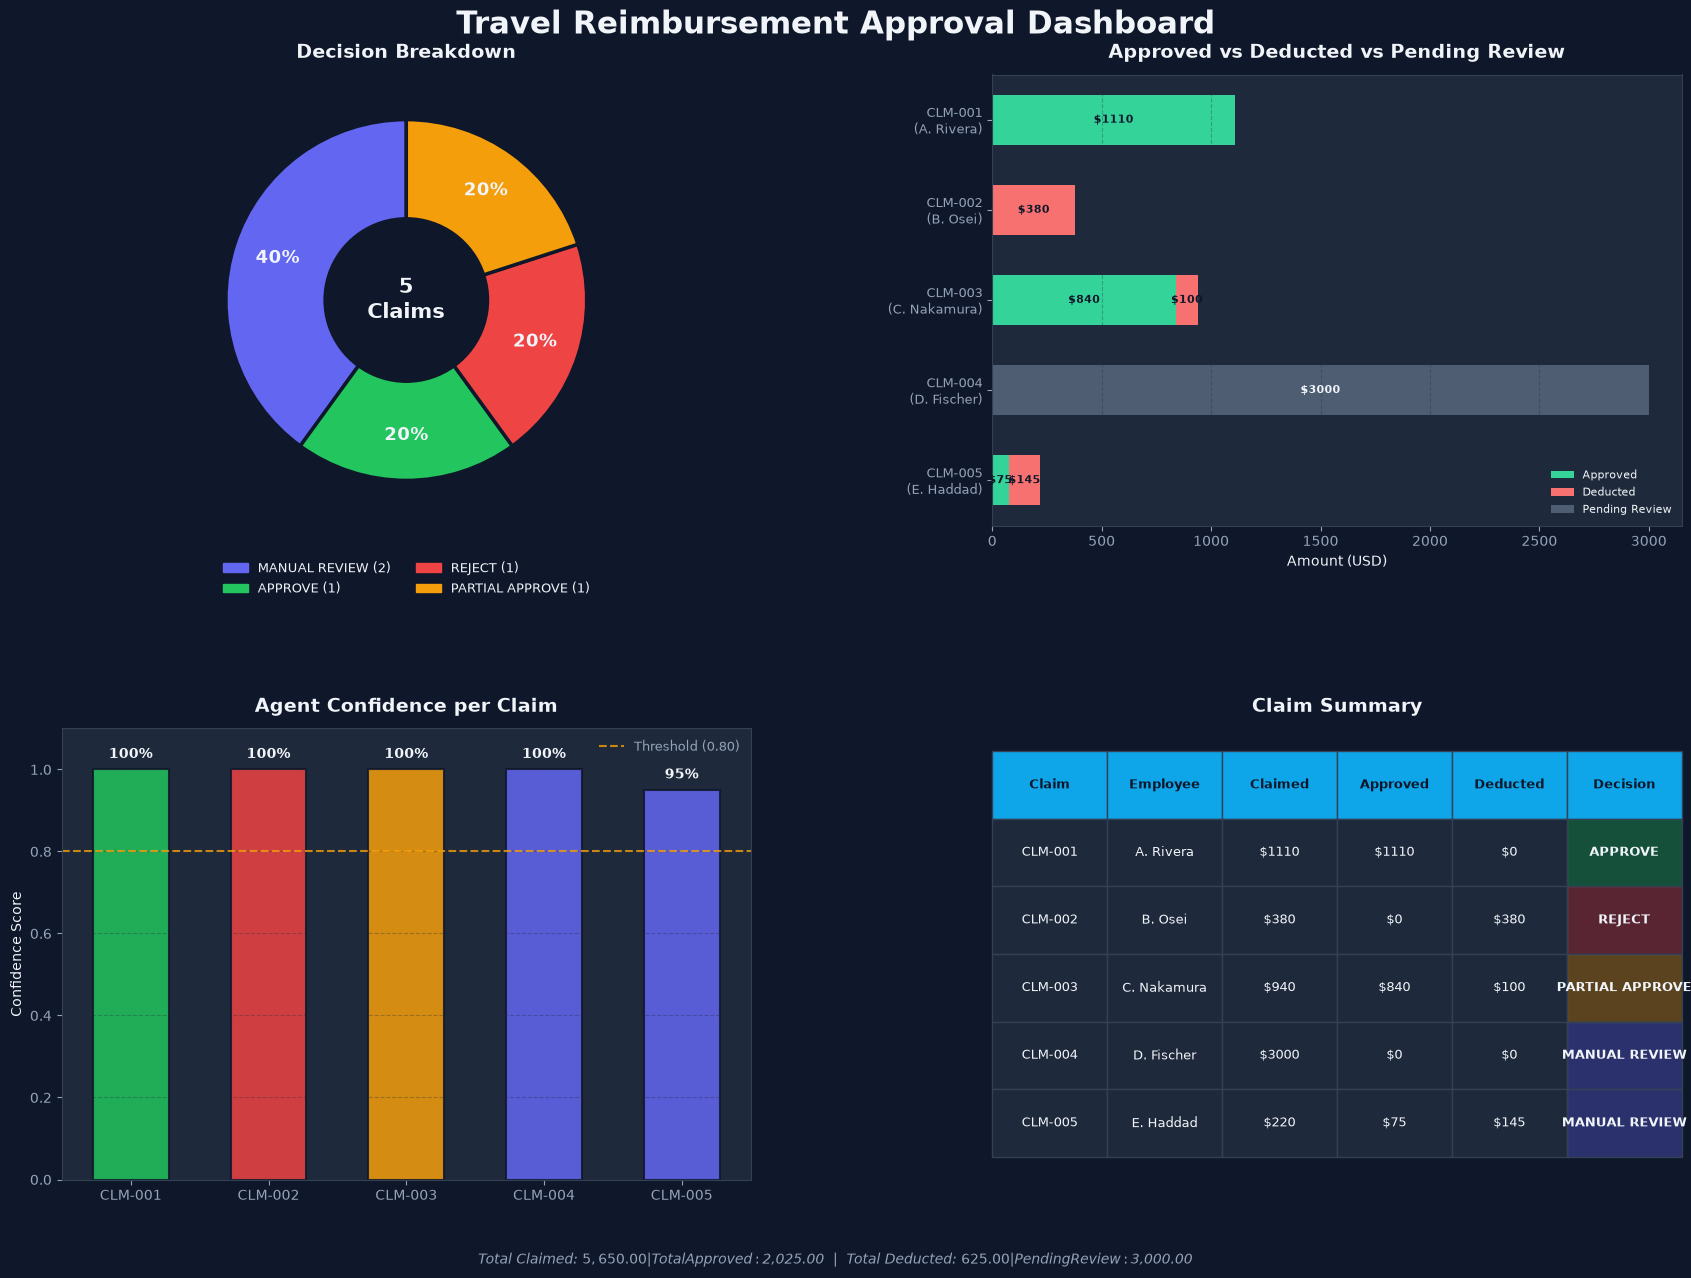


Dashboard saved as "UI SS_1.png"

Summary:
  Total Claimed  : $5,650.00
  Total Approved : $2,025.00
  Total Deducted : $625.00
  Pending Review : $3,000.00


In [9]:
# Cell 12: Results Dashboard
## Dashboard

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PALETTE = {
    'APPROVE':         '#22c55e',
    'PARTIAL_APPROVE': '#f59e0b',
    'REJECT':          '#ef4444',
    'MANUAL_REVIEW':   '#6366f1',
    'bg':              '#0f172a',
    'card':            '#1e293b',
    'text':            '#f1f5f9',
    'subtext':         '#94a3b8',
    'approved_bar':    '#34d399',
    'deducted_bar':    '#f87171',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['bg'],  'axes.facecolor': PALETTE['card'],
    'axes.edgecolor': '#334155',        'axes.labelcolor': PALETTE['text'],
    'xtick.color': PALETTE['subtext'],  'ytick.color': PALETTE['subtext'],
    'text.color': PALETTE['text'],      'grid.color': '#1e293b',
    'grid.linestyle': '--',             'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
})

df = pd.DataFrame(validated_results)
df['employee']      = [c['employee'] for c in CLAIMS]
df['total_claimed'] = [c['total_claimed'] for c in CLAIMS]

fig = plt.figure(figsize=(18, 13), facecolor=PALETTE['bg'])
fig.suptitle('Travel Reimbursement Approval Dashboard',
             fontsize=22, fontweight='bold', color=PALETTE['text'], y=0.97)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.97, top=0.92, bottom=0.07)

# --- Chart 1: Decision Donut ---
ax1 = fig.add_subplot(gs[0, 0])
decision_counts = df['decision'].value_counts()
labels = decision_counts.index.tolist()
sizes  = decision_counts.values
colors = [PALETTE.get(d, '#888') for d in labels]

wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, colors=colors, autopct='%1.0f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor=PALETTE['bg'], linewidth=2.5),
    textprops={'color': PALETTE['text'], 'fontsize': 13, 'fontweight': 'bold'},
)
ax1.text(0, 0, f'{len(df)}\nClaims', ha='center', va='center',
         fontsize=15, fontweight='bold', color=PALETTE['text'])
legend_patches = [
    mpatches.Patch(color=PALETTE.get(d, '#888'), label=f'{d.replace("_", " ")} ({c})')
    for d, c in zip(labels, sizes)
]
ax1.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9, frameon=False, labelcolor=PALETTE['text'])
ax1.set_title('Decision Breakdown', fontsize=14, fontweight='bold', color=PALETTE['text'], pad=12)

# --- Chart 2: Approved vs Deducted vs Pending ---
ax2 = fig.add_subplot(gs[0, 1])
claim_labels = [f"{r['claim_id']}\n({e})" for r, e in zip(validated_results, df['employee'])]
approved  = df['approved_amount'].values
deducted  = df['deducted_amount'].values
total_cls = df['total_claimed'].values
pending   = np.maximum(0, total_cls - approved - deducted)
y_pos     = np.arange(len(claim_labels))

ax2.barh(y_pos, approved, height=0.55, color=PALETTE['approved_bar'], label='Approved')
ax2.barh(y_pos, deducted, height=0.55, left=approved, color=PALETTE['deducted_bar'], label='Deducted')
ax2.barh(y_pos, pending,  height=0.55, left=approved+deducted, color='#64748b', label='Pending Review', alpha=0.7)

for i, (a, d, p) in enumerate(zip(approved, deducted, pending)):
    if a > 30: ax2.text(a/2, i, f'${a:.0f}', ha='center', va='center', fontsize=8, fontweight='bold', color='#0f172a')
    if d > 30: ax2.text(a+d/2, i, f'${d:.0f}', ha='center', va='center', fontsize=8, fontweight='bold', color='#0f172a')
    if p > 30: ax2.text(a+d+p/2, i, f'${p:.0f}', ha='center', va='center', fontsize=8, fontweight='bold', color=PALETTE['text'])

ax2.set_yticks(y_pos)
ax2.set_yticklabels(claim_labels, fontsize=9)
ax2.set_xlabel('Amount (USD)', fontsize=10)
ax2.set_title('Approved vs Deducted vs Pending Review', fontsize=14,
              fontweight='bold', color=PALETTE['text'], pad=12)
ax2.legend(loc='lower right', fontsize=8, frameon=False, labelcolor=PALETTE['text'])
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# --- Chart 3: Confidence Bars ---
ax3 = fig.add_subplot(gs[1, 0])
confidences = df['confidence'].values
decisions   = df['decision'].values
dot_colors  = [PALETTE.get(d, '#888') for d in decisions]
x_pos       = np.arange(len(validated_results))

bars = ax3.bar(x_pos, confidences, color=dot_colors, alpha=0.85, width=0.55,
               edgecolor=PALETTE['bg'], linewidth=1.5)
ax3.axhline(0.8, color='#f59e0b', linestyle='--', linewidth=1.5, alpha=0.8, label='Threshold (0.80)')
for i, (val, bar) in enumerate(zip(confidences, bars)):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.0%}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color=PALETTE['text'])
ax3.set_xticks(x_pos)
ax3.set_xticklabels([r['claim_id'] for r in validated_results], fontsize=10)
ax3.set_ylim(0, 1.1)
ax3.set_ylabel('Confidence Score', fontsize=10)
ax3.set_title('Agent Confidence per Claim', fontsize=14, fontweight='bold', color=PALETTE['text'], pad=12)
ax3.legend(fontsize=9, frameon=False, labelcolor=PALETTE['subtext'])
ax3.grid(axis='y', alpha=0.3)

# --- Chart 4: Summary Table ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
ax4.set_title('Claim Summary', fontsize=14, fontweight='bold', color=PALETTE['text'], pad=12)

table_data = []
for r, c in zip(validated_results, CLAIMS):
    dec_label = r['decision'].replace('_', ' ')
    table_data.append([
        r['claim_id'], c['employee'],
        f"${c['total_claimed']:.0f}",
        f"${r['approved_amount']:.0f}",
        f"${r['deducted_amount']:.0f}",
        dec_label,
    ])

col_labels = ['Claim', 'Employee', 'Claimed', 'Approved', 'Deducted', 'Decision']
table = ax4.table(cellText=table_data, colLabels=col_labels,
                  cellLoc='center', loc='center', bbox=[0, 0.05, 1, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#0ea5e9')
        cell.set_text_props(color=PALETTE['bg'], fontweight='bold')
    else:
        dec = validated_results[row-1]['decision']
        if col == 5:
            base = PALETTE.get(dec, '#64748b')
            cell.set_facecolor(base + '55')
            cell.set_text_props(color=PALETTE['text'], fontweight='bold')
        else:
            cell.set_facecolor(PALETTE['card'])
            cell.set_text_props(color=PALETTE['text'])
    cell.set_edgecolor('#334155')

# Footer stats
total_approved    = sum(r['approved_amount'] for r in validated_results)
total_deducted    = sum(r['deducted_amount'] for r in validated_results)
total_claimed_all = sum(c['total_claimed'] for c in CLAIMS)
pending_review    = total_claimed_all - total_approved - total_deducted

stats_text = (f'Total Claimed: ${total_claimed_all:,.2f}  |  '
              f'Total Approved: ${total_approved:,.2f}  |  '
              f'Total Deducted: ${total_deducted:,.2f}  |  '
              f'Pending Review: ${pending_review:,.2f}')
fig.text(0.5, 0.005, stats_text, ha='center', fontsize=10, color=PALETTE['subtext'], style='italic')

plt.savefig('UI SS_1.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print('\nDashboard saved as "UI SS_1.png"')
print(f'\nSummary:')
print(f'  Total Claimed  : ${total_claimed_all:,.2f}')
print(f'  Total Approved : ${total_approved:,.2f}')
print(f'  Total Deducted : ${total_deducted:,.2f}')
print(f'  Pending Review : ${pending_review:,.2f}')

In [10]:
# Cell 13: Sample Outputs -- Three Example Claims (CLM-001, CLM-003, CLM-004)

SAMPLE_IDS = ['CLM-001', 'CLM-003', 'CLM-004']
sample_results = {r['claim_id']: r for r in validated_results if r['claim_id'] in SAMPLE_IDS}
sample_claims  = {c['claim_id']: c for c in CLAIMS       if c['claim_id'] in SAMPLE_IDS}

for cid in SAMPLE_IDS:
    r = sample_results.get(cid)
    c = sample_claims.get(cid)
    if not r or not c:
        continue

    sep = '=' * 70
    print(f'\n{sep}')
    print(f'  {cid}: {c["purpose"]}')
    print(sep)
    print(f'  Employee      : {c["employee"]}')
    print(f'  Trip          : {c["trip_start"]} to {c["trip_end"]}')
    print(f'  Submitted     : {c["submission_date"]}')
    print(f'  Total Claimed : ${c["total_claimed"]:.2f}')
    print(f'  ---')
    print(f'  Decision       : {r["decision"]}')
    print(f'  Approved       : ${r["approved_amount"]:.2f}')
    print(f'  Deducted       : ${r["deducted_amount"]:.2f}')
    print(f'  Confidence     : {r["confidence"]:.0%}')
    print(f'  Policy Refs    : {", ".join(r["policy_refs"])}')
    print(f'  Tools Used     : {", ".join(r["tools_used"])}')
    if r.get('missing_docs'):
        print(f'  Missing Docs   : {", ".join(r["missing_docs"])}')
    print(f'  Explanation    :')
    # Word-wrap explanation at 66 chars
    words, line = r['explanation'].split(), ''
    for w in words:
        if len(line) + len(w) + 1 <= 66:
            line = (line + ' ' + w).strip()
        else:
            print(f'    {line}')
            line = w
    if line:
        print(f'    {line}')
print(f'\n{"=" * 70}')


  CLM-001: Attend 2-day industry conference (business)
  Employee      : A. Rivera
  Trip          : 2026-06-10 to 2026-06-12
  Submitted     : 2026-06-20
  Total Claimed : $1110.00
  ---
  Decision       : APPROVE
  Approved       : $1110.00
  Deducted       : $0.00
  Confidence     : 100%
  Policy Refs    : POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01, POL-APR-02, POL-TIME-01
  Tools Used     : calculate_per_diem_limits, check_approval_threshold, check_receipt_completeness, check_timeliness
  Explanation    :
    The claim is fully compliant with company policy. It was submitted
    within the 30-day window (POL-TIME-01), all required receipts are
    attached (POL-RCT-01), all items are eligible (POL-CAT-01), and
    all costs are within per-diem limits for meals (POL-PD-01) and
    lodging (POL-PD-02). The total amount falls within the
    manager-approvable threshold (POL-APR-02).

  CLM-003: Client site visit (business)
  Employee      : C. Nakamura
  Trip          : 2026-06-08 